# India Paper Leak Incidents Analysis

This project analyzes recorded paper-leak incidents in India using Python for data analysis and a simple machine learning model.

The analysis focuses on:
- Trends in recorded incidents over the years
- Leak status distribution
- Affected areas
- Conducting bodies
- Frequently occurring examinations
- A simple classification model for recorded incidents

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Loading and Understanding the Dataset

The dataset is loaded from an Excel file and its basic structure is examined before performing further analysis.

In [46]:
df = pd.read_excel("India_Paper_Leaks_Cleaned.xlsx")
df.head()

,Incident_Id,Date,Era,Exam_Name,Conducting_Body,Body_Type,Area,Leak_Status,Action_taken,Note,Incident_type
0,PL - 0001,2004-04-11,UPA (2004 - May2014),All India Pre - Medical Test (AIPMT/CBSE - PMT...,CBSE,Central,All India,Confirmed,Exam cancelled + Arrests - FIR + Probe (CBI/SIT),Physics and chemistry papers leaked in New Del...,Paper Leak
1,PL - 0002,2006-06-01,UPA (2004 - May2014),Himachal Pradesh Combined Pre - Medical Test (...,Himachal Pradesh University,State,Himachal Pradesh,Confirmed,Retest + Arrests - FIR,HP - CPMT medical entrance paper leaked via a ...,Paper Leak
2,PL - 0003,2008-01-01,UPA (2004 - May2014),Vyapam Patwari Recruitment Examination 2008,Madhya Pradesh Professional Examination Board ...,State,Madhya Pradesh,Confirmed,Arrests - FIR + Probe (CBI/SIT),Accused produced forged educational certificat...,Other Exam Irregularity
3,PL - 0004,2009-07-08,UPA (2004 - May2014),MP Pre - Medical Test (PMT) 2009,Madhya Pradesh Professional Examination Board ...,State,Madhya Pradesh,Confirmed,Arrests - FIR + Probe (CBI/SIT),Paid solvers/impersonators sat the exam in pla...,Impersonation
4,PL - 0005,2010-06-06,UPA (2004 - May2014),RRB Mumbai 2010 recruitment exam (Assistant Lo...,"Railway Recruitment Board (RRB), Mumbai",Central,All India,Confirmed,Arrests - FIR + Probe (CBI/SIT),CBI registered a case on 15 June 2010 over the...,Paper Leak


In [47]:
print(df.shape)

(110, 11)


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Incident_Id      110 non-null    str           
 1   Date             110 non-null    datetime64[us]
 2   Era              110 non-null    str           
 3   Exam_Name        110 non-null    str           
 4   Conducting_Body  110 non-null    str           
 5   Body_Type        110 non-null    str           
 6   Area             110 non-null    str           
 7   Leak_Status      110 non-null    str           
 8   Action_taken     110 non-null    str           
 9   Note             110 non-null    str           
 10  Incident_type    110 non-null    str           
dtypes: datetime64[us](1), str(10)
memory usage: 9.6 KB


## 2. Initial Data Inspection

The dataset is inspected using summary statistics and basic column-level checks to understand the structure and values before analysis.

In [49]:
df.describe()

,Date
count,110
mean,2019-08-23 20:43:38.181818
min,2004-04-11 00:00:00
25%,2015-11-26 00:00:00
50%,2021-09-29 12:00:00
75%,2023-05-21 12:00:00
max,2026-07-19 00:00:00


### Data Types and Categorical Values

The data types of the variables and the unique categorical values are examined to understand how the dataset is structured and how the variables can be used in further analysis.

In [50]:
print(df['Body_Type'].unique())

<StringArray>
['Central', 'State']
Length: 2, dtype: str


In [51]:
print(df['Leak_Status'].unique)

<bound method Series.unique of 0      Confirmed
1      Confirmed
2      Confirmed
3      Confirmed
4      Confirmed
         ...    
105    Confirmed
106      Alleged
107    Confirmed
108      Alleged
109       Denied
Name: Leak_Status, Length: 110, dtype: str>


### Incident Type and Data Quality Check

The incident types are reviewed to understand the categories present in the dataset. A basic data-quality check is then performed to identify missing values and duplicate rows.

In [52]:
print(df['Incident_type'].unique())

<StringArray>
[                       'Paper Leak',           'Other Exam Irregularity',
                     'Impersonation', 'Marks/Answer - Sheet Manipulation',
        'Cheating/Answer Assistance']
Length: 5, dtype: str


In [53]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Incident_Id        0
Date               0
Era                0
Exam_Name          0
Conducting_Body    0
Body_Type          0
Area               0
Leak_Status        0
Action_taken       0
Note               0
Incident_type      0
dtype: int64

Duplicate rows: 0


In [54]:
df["Year"] = pd.to_datetime(df['Date']).dt.year

## 3. Year-wise Analysis

The number of recorded incidents is analyzed year-wise to identify trends and changes over time.

In [55]:
yearly_incidents = df["Year"].value_counts().sort_index()
print(yearly_incidents)


Year
2004     1
2006     1
2008     1
2009     1
2010     1
2011     5
2012     8
2013     5
2014     2
2015     3
2016     3
2017     5
2018     5
2019     2
2020     4
2021    14
2022    15
2023    11
2024    12
2025     5
2026     6
Name: count, dtype: int64


In [56]:
highest_year = yearly_incidents.idxmax()
highest_count = yearly_incidents.max()

print(
    f"Year with the highest number of recorded incidents: "
    f"{highest_year} ({highest_count} incidents)"
)

Year with the highest number of recorded incidents: 2022 (15 incidents)


In [57]:
lowest_year = yearly_incidents.idxmin()
lowest_count = yearly_incidents.min()

print(
    f"Year with the lowest number of recorded incidents: "
    f"{lowest_year} ({lowest_count} incidents)"
)

Year with the lowest number of recorded incidents: 2004 (1 incidents)


In [58]:
# check incidents by status
status_counts = df['Leak_Status'].value_counts()
print(status_counts)

status_percentage = df['Leak_Status'].value_counts(normalize=True) * 100
print(status_percentage.round(2))

Leak_Status
Confirmed    89
Alleged      13
Denied        5
Suspected     3
Name: count, dtype: int64
Leak_Status
Confirmed    80.91
Alleged      11.82
Denied        4.55
Suspected     2.73
Name: proportion, dtype: float64


## 4. Categorical Analysis

The distribution of recorded incidents is analyzed across body types and affected areas to identify the categories and locations that appear most frequently in the dataset.

In [59]:
body_type_counts = df['Body_Type'].value_counts()
print(body_type_counts)

Body_Type
State      88
Central    22
Name: count, dtype: int64


In [60]:
location_counts = df['Area'].value_counts()
print(location_counts.to_string())

Area
All India                    16
Madhya Pradesh               13
Uttar Pradesh                12
Rajasthan                    11
Uttarakhand                   6
Bihar                         6
Haryana                       5
Gujarat                       5
Maharashtra                   5
Punjab                        4
Jharkhand                     4
Himachal Pradesh              3
Chhattisgarh                  3
Delhi                         3
Karnataka                     2
Assam                         2
Andaman & Nicobar Islands     1
Jammu & Kashmir               1
Manipur                       1
West Bengal                   1
Bihar & Jharkhand             1
Tamil Nadu                    1
Andhra Pradesh                1
Arunachal Pradesh             1
Telangana                     1
Odisha                        1


In [61]:
most_affected_area = location_counts.idxmax()
most_affected_count = location_counts.max()

print(
    f"Area with the highest number of recorded incidents: "
    f"{most_affected_area} ({most_affected_count} incidents)"
)

Area with the highest number of recorded incidents: All India (16 incidents)


### Area-wise Comparison

The affected areas are further examined by reviewing the unique area categories and comparing states and union territories based on their recorded incident counts. The "All India" category is excluded when comparing individual states and union territories.

In [62]:
print("Number of unique locations: " , df['Area'].nunique())

Number of unique locations:  26


In [63]:
state_counts = df[df['Area'] != 'All India']['Area'].value_counts()

print("Top 10 states/UTs by recorded incidents:")
print(state_counts.head(10))

Top 10 states/UTs by recorded incidents:
Area
Madhya Pradesh    13
Uttar Pradesh     12
Rajasthan         11
Uttarakhand        6
Bihar              6
Haryana            5
Gujarat            5
Maharashtra        5
Punjab             4
Jharkhand          4
Name: count, dtype: int64


In [64]:
# realtion between central and state w.r.t status
# For Central and State examinations, how many incidents fall into each status?"
body_status = pd.crosstab(df['Body_Type'] , df['Leak_Status'])
print(body_status)

Leak_Status  Alleged  Confirmed  Denied  Suspected
Body_Type                                         
Central            1         18       2          1
State             12         71       3          2


### Leak Status Across Years

The relationship between year and leak status is examined to observe how the recorded status of incidents varies over time.

In [65]:
# For each year, how many incidents were Alleged, Confirmed, Denied, or Suspected?"
yearly_status = pd.crosstab(df['Year'] , df['Leak_Status'])
print(yearly_status)

Leak_Status  Alleged  Confirmed  Denied  Suspected
Year                                              
2004               0          1       0          0
2006               0          1       0          0
2008               0          1       0          0
2009               0          1       0          0
2010               0          1       0          0
2011               0          5       0          0
2012               0          8       0          0
2013               0          5       0          0
2014               1          1       0          0
2015               0          3       0          0
2016               0          2       1          0
2017               1          4       0          0
2018               0          5       0          0
2019               0          2       0          0
2020               0          4       0          0
2021               1         13       0          0
2022               2         13       0          0
2023               4          6

### Yearly Variation

Mean, median, and standard deviation are calculated to understand the typical number of recorded incidents per year and the variation around that level.

In [66]:
average_incidents = yearly_incidents.mean()
median_incidents = yearly_incidents.median()
std_incidents = yearly_incidents.std()

print(f"Mean yearly incidents: {average_incidents:.2f}")
print(f"Median yearly incidents: {median_incidents:.2f}")
print(f"Standard deviation: {std_incidents:.2f}")

Mean yearly incidents: 5.24
Median yearly incidents: 5.00
Standard deviation: 4.37


### Identifying High-Incident Years

An exploratory threshold based on the mean and standard deviation is used to identify years with comparatively high numbers of recorded incidents.

In [67]:
threshold = average_incidents + std_incidents

high_incident_years = yearly_incidents[
    yearly_incidents > threshold
]

print(f"Exploratory high-incident threshold: {threshold:.2f}")
print("\nYears above this threshold:")
print(high_incident_years)

Exploratory high-incident threshold: 9.61

Years above this threshold:
Year
2021    14
2022    15
2023    11
2024    12
Name: count, dtype: int64


### Year-to-Year Change

The change in the number of recorded incidents from one year to the next is calculated to identify periods of noticeable increase or decrease.

In [68]:
yearly_change = yearly_incidents.diff()

print("Year-to-year change in recorded incidents:")
print(yearly_change)

Year-to-year change in recorded incidents:
Year
2004     NaN
2006     0.0
2008     0.0
2009     0.0
2010     0.0
2011     4.0
2012     3.0
2013    -3.0
2014    -3.0
2015     1.0
2016     0.0
2017     2.0
2018     0.0
2019    -3.0
2020     2.0
2021    10.0
2022     1.0
2023    -4.0
2024     1.0
2025    -7.0
2026     1.0
Name: count, dtype: float64


### Largest Increase

The year with the largest increase in recorded incidents compared with the previous year is identified.

In [69]:
biggest_increase_year = yearly_change.idxmax()
biggest_increase = yearly_change.max()

print(
    f"Biggest year-to-year increase: "
    f"{biggest_increase_year} (+{int(biggest_increase)} incidents)"
)

Biggest year-to-year increase: 2021 (+10 incidents)


### Largest Decrease

The year with the largest decrease in recorded incidents compared with the previous year is identified.

In [70]:
biggest_decrease_year = yearly_change.idxmin()
biggest_decrease = yearly_change.min()

print(
    f"Biggest year-to-year decrease: "
    f"{biggest_decrease_year} ({int(biggest_decrease)} incidents)"
)

Biggest year-to-year decrease: 2025 (-7 incidents)


## 5. Conducting Body Analysis

The dataset is analyzed by conducting body to identify organizations that appear most frequently among the recorded incidents.

In [71]:
conducting_body_counts = df['Conducting_Body'].value_counts()
print(conducting_body_counts.to_string())

Conducting_Body
Madhya Pradesh Professional Examination Board (Vyapam)                 12
CBSE                                                                    9
Uttarakhand Subordinate Service Selection Commission (UKSSSC)           4
Rajasthan Staff Selection Board (RSMSSB)                                4
NTA                                                                     4
Rajasthan Public Service Commission (RPSC)                              3
Bihar Public Service Commission (BPSC)                                  3
Jharkhand Staff Selection Commission (JSSC)                             3
All India Institute of Medical Sciences (AIIMS)                         2
Staff Selection Commission (SSC)                                        2
Delhi Subordinate Services Selection Board (DSSSB)                      2
Uttar Pradesh Public Service Commission (UPPSC)                         2
Haryana Board of School Education (HBSE)                                2
Bihar Staff Selection 

### Highest and Lowest Recorded Incidents

The conducting bodies with the highest and lowest numbers of recorded incidents are identified within this dataset.

In [72]:
highest_body = conducting_body_counts.idxmax()
highest_body_count = conducting_body_counts.max()

lowest_body = conducting_body_counts.idxmin()
lowest_body_count = conducting_body_counts.min()

print(
    f"Conducting body with the highest number of recorded incidents: "
    f"{highest_body} ({highest_body_count} incidents)"
)

print(
    f"Conducting body with the lowest number of recorded incidents: "
    f"{lowest_body} ({lowest_body_count} incidents)"
)

Conducting body with the highest number of recorded incidents: Madhya Pradesh Professional Examination Board (Vyapam) (12 incidents)
Conducting body with the lowest number of recorded incidents: Himachal Pradesh University (1 incidents)


### Top Conducting Bodies

The five conducting bodies with the highest numbers of recorded incidents are identified for comparison.

In [73]:
print("Top 5 Conducting Bodies with highest number of paper leaks:\n" , conducting_body_counts.head(5))

Top 5 Conducting Bodies with highest number of paper leaks:
 Conducting_Body
Madhya Pradesh Professional Examination Board (Vyapam)           12
CBSE                                                              9
Uttarakhand Subordinate Service Selection Commission (UKSSSC)     4
Rajasthan Staff Selection Board (RSMSSB)                          4
NTA                                                               4
Name: count, dtype: int64


## 6. Examination Analysis

The frequency of examinations in the dataset is analyzed to identify which examinations appear most often among the recorded incidents.

In [74]:
exam_counts = df['Exam_Name'].value_counts()

print("Top 10 exams by recorded incidents:")
print(exam_counts.head(10))

Top 10 exams by recorded incidents:
Exam_Name
Forest Guard recruitment exam                                                                       2
All India Pre - Medical Test (AIPMT/CBSE - PMT) 2004                                                1
Himachal Pradesh Combined Pre - Medical Test (HP - CPMT) 2006                                       1
Vyapam Patwari Recruitment Examination 2008                                                         1
MP Pre - Medical Test (PMT) 2009                                                                    1
RRB Mumbai 2010 recruitment exam (Assistant Loco Pilot / Assistant Station Master)                  1
Vyapam Contract Teacher Eligibility Test (Samvida Shala Shikshak Patrata Pariksha Varg - 3) 2011    1
CBSE Class 10 & Class 12 Board Examinations 2011                                                    1
AIEEE (All India Engineering Entrance Examination) 2011                                             1
Chhattisgarh Pre - Medical Test (CG 

### Most Frequently Recorded Examination

The examination with the highest number of recorded incidents is identified based on its frequency in the dataset.

In [75]:
highest_exam = exam_counts.idxmax()
highest_exam_count = exam_counts.max()

print(
    f"Exam with the highest number of recorded incidents: "
    f"{highest_exam} ({highest_exam_count} incidents)"
)

Exam with the highest number of recorded incidents: Forest Guard recruitment exam (2 incidents)


## 7. Machine Learning

A simple classification model is built to classify the recorded incidents based on whether their leak status is **Confirmed** or **Not Confirmed**.

The target variable is created as:
- `1` → Confirmed
- `0` → Alleged, Suspected, or Denied

The model is intended as an exploratory classification exercise on the available dataset. It does not predict whether a future examination will experience a paper leak, because the dataset contains recorded leak incidents rather than a complete set of examinations with both leak and non-leak cases.

In [76]:
df["Confirmed_target"] = np.where(
    df['Leak_Status'] == 'Confirmed',
    1,
    0
)

print(df[['Leak_Status','Confirmed_target']].head(10))

  Leak_Status  Confirmed_target
0   Confirmed                 1
1   Confirmed                 1
2   Confirmed                 1
3   Confirmed                 1
4   Confirmed                 1
5   Confirmed                 1
6   Confirmed                 1
7   Confirmed                 1
8   Confirmed                 1
9   Confirmed                 1


In [77]:
target_counts = df["Confirmed_target"].value_counts().sort_index()

print("Target distribution:")
print(target_counts)

print("\nClass labels:")
print("0 = Not Confirmed")
print("1 = Confirmed")

Target distribution:
Confirmed_target
0    21
1    89
Name: count, dtype: int64

Class labels:
0 = Not Confirmed
1 = Confirmed


### Feature Selection

The model uses year, examination, conducting body, body type, area, and incident type as input features. The incident ID is excluded because it is only an identifier, while leak status is excluded because it is used to create the target variable.

In [78]:
features = [
    "Year",
    "Exam_Name",
    "Conducting_Body",
    "Body_Type",
    "Area",
    "Incident_type"
]

X = df[features]
y = df["Confirmed_target"]

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (88, 6)
Testing set: (22, 6)


In [80]:
categorical_features = [
    "Exam_Name",
    "Conducting_Body",
    "Body_Type",
    "Area",
    "Incident_type"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training data:", X_train_encoded.shape)
print("Encoded testing data:", X_test_encoded.shape)

Encoded training data: (88, 167)
Encoded testing data: (22, 167)


### Decision Tree Classification

A Decision Tree classifier is used to classify recorded incidents as Confirmed or Not Confirmed. Class balancing is applied because the target classes are unevenly distributed.

In [81]:
model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    class_weight="balanced"
)

model.fit(X_train_encoded, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

In [82]:
y_pred = model.predict(X_test_encoded)

print("Predicted values:")
print(y_pred)

print("\nActual values:")
print(y_test.values)

Predicted values:
[1 1 1 1 1 0 1 0 1 0 0 1 0 0 1 0 0 0 1 1 0 0]

Actual values:
[1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1]


### Model Accuracy

Accuracy is calculated to measure the proportion of test-set records that were classified correctly.

In [83]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model accuracy: {accuracy:.2%}")

Model accuracy: 59.09%


### Model Evaluation

The model is evaluated using a confusion matrix and classification report to examine how well it distinguishes between Confirmed and Not Confirmed recorded incidents.

In [84]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 3  1]
 [ 8 10]]


In [85]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Confirmed", "Confirmed"]
    )
)

Classification Report:
               precision    recall  f1-score   support

Not Confirmed       0.27      0.75      0.40         4
    Confirmed       0.91      0.56      0.69        18

     accuracy                           0.59        22
    macro avg       0.59      0.65      0.54        22
 weighted avg       0.79      0.59      0.64        22



### Decision Tree Visualization

The trained decision tree is visualized to provide a simple view of the decision rules learned by the model.

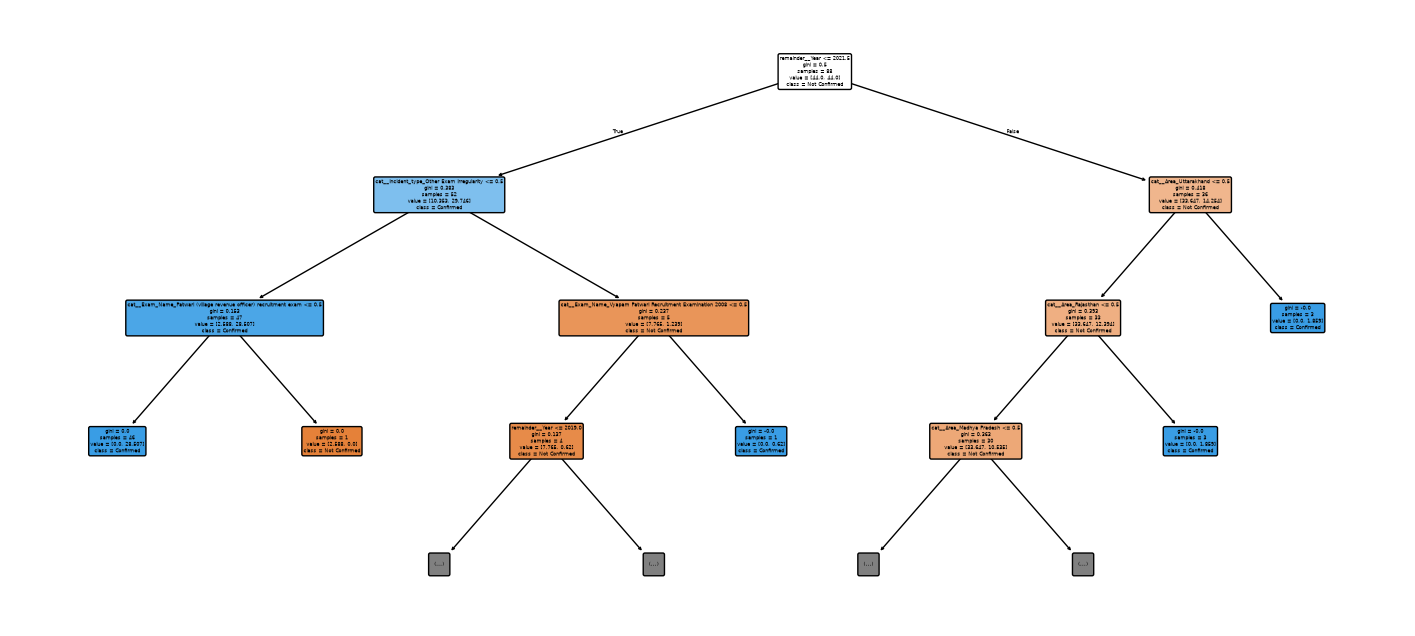

In [86]:
plt.figure(figsize=(18, 8))

plot_tree(
    model,
    max_depth=3,
    filled=True,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=["Not Confirmed", "Confirmed"],
    rounded=True
)

plt.show()

## 8. Conclusion

This project analyzed 110 recorded paper-leak incidents in India using Python and Power BI.

The analysis examined:
- Year-wise trends in recorded incidents
- Leak status distribution
- Affected areas
- Conducting bodies
- Frequently recorded examinations
- Changes in incidents across years

A Decision Tree classifier was also developed to classify recorded incidents as Confirmed or Not Confirmed. The model was evaluated using accuracy, a confusion matrix, and a classification report.

The machine learning model is exploratory because the dataset contains recorded leak incidents rather than a complete set of examinations with both leak and non-leak outcomes. Therefore, the model should not be interpreted as a predictor of future paper leaks.

Overall, the project demonstrates the use of Python for data cleaning, exploratory analysis, visualization preparation, and basic machine learning, along with Power BI for interactive data visualization.